In [1]:
import pysam
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import warnings


In [2]:
def is_empty_vcf(vcf_file):
    vcf = pysam.VariantFile(vcf_file)
    for _ in vcf:
        return False
    return True

In [ ]:
vcf_dir = "full_data"
vcf_files = sorted(os.listdir(vcf_dir))
vcf_files = [vcf_file for vcf_file in vcf_files if vcf_file.endswith(".vcf.gz")]
vcf_files = [os.path.join(vcf_dir, vcf_file) for vcf_file in vcf_files]
vcf_files = [vcf_file for vcf_file in vcf_files if not is_empty_vcf(vcf_file)]
sample_file = pysam.VariantFile(vcf_files[0])

In [6]:
vcf_files = ["full_data/ClinVar.hg19.full.vcf.gz"]
sample_file = pysam.VariantFile(vcf_files[0])

In [19]:
def read_tsv(path):
    return pd.read_csv(path, sep='\t', na_values='-', low_memory=False)

In [20]:
full_build_df = read_tsv("release/built_with_change_types.tsv")

In [21]:
# remove decimal from SCV by splitting on "." and taking the first part
full_build_df["ClinVarAccession_ENIGMA"] = full_build_df["ClinVarAccession_ENIGMA"].apply(lambda x: str(x).split(".")[0] if str(x) != "nan" else x)

In [ ]:
# count = 0
# af = full_build_df["Allele_Frequency"]
# sub = full_build_df["Submitter_ClinVar"]
# scv = full_build_df["ClinVarAccession_ENIGMA"]
# for i, j, k in zip(af, sub, scv):
# 	if str(i) != "nan" and str(j) != "nan" and "enigma" in j.lower():
# 		print(i, k)
# 		count += 1	
# print(count)

In [ ]:
def get_af_from_hgvs(hgvs):
    hgvs_arr = hgvs.split(".")
    # print(hgvs_arr)
    hgvs = hgvs_arr[0] + "." + hgvs_arr[1] + ":" + hgvs_arr[2] + "." + hgvs_arr[3]
    # print(hgvs)
    # print(full_build_df.loc[full_build_df['HGVS_cDNA_LOVD'] == hgvs])
    val = full_build_df.loc[full_build_df['HGVS_cDNA_LOVD'] == hgvs, 'Allele_Frequency'].values
    # print(val)
    if len(val) == 0 or str(val[0]) == 'nan':
        return -1
    return float(val[0].split(" ")[0])

In [24]:
def get_af_from_scv(scv):
    val = full_build_df.loc[full_build_df['ClinVarAccession_ENIGMA'] == scv, 'Allele_Frequency'].values
    if len(val) == 0 or str(val[0]) == 'nan':
        return -1
    return float(val[0].split(" ")[0])

In [25]:
print(get_af_from_scv("SCV000321094"))

0.003798


In [26]:
fields = set(sample_file.header.info.keys())
print(f"Fields: {fields}")

Fields: {'ConditionType', 'SCV', 'ID', 'ReviewStatus', 'Symbol', 'Origin', 'ConditionDB_ID', 'DateSignificanceLastEvaluated', 'ConditionValue', 'CSQ', 'Method', 'Protein', 'DateLastUpdated', 'HGVS', 'Submitter', 'Genomic_Coordinate', 'Description', 'SummaryEvidence', 'SCV_Version', 'ClinicalSignificance', 'Synonyms'}


In [27]:
csq_fields = {}
for tag in fields:
	desc = sample_file.header.info[tag].description
	
	if tag == "CSQ":
		desc = desc.split(":")[1]
		desc = desc.split("|")
		for i in range(len(desc) - 1):
			field = desc[i]
			csq_fields[field] = i

In [28]:
print(csq_fields.keys())

dict_keys([' Allele', 'Consequence', 'IMPACT', 'SYMBOL', 'Gene', 'Feature_type', 'Feature', 'BIOTYPE', 'EXON', 'INTRON', 'HGVSc', 'HGVSp', 'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids', 'Codons', 'Existing_variation', 'DISTANCE', 'STRAND', 'FLAGS', 'SYMBOL_SOURCE', 'HGNC_ID', 'CANONICAL', '1000Gp3_AC', '1000Gp3_AF', '1000Gp3_AFR_AC', '1000Gp3_AFR_AF', '1000Gp3_AMR_AC', '1000Gp3_AMR_AF', '1000Gp3_EAS_AC', '1000Gp3_EAS_AF', '1000Gp3_EUR_AC', '1000Gp3_EUR_AF', '1000Gp3_SAS_AC', '1000Gp3_SAS_AF', 'ALFA_African_AC', 'ALFA_African_AF', 'ALFA_African_AN', 'ALFA_African_American_AC', 'ALFA_African_American_AF', 'ALFA_African_American_AN', 'ALFA_African_Others_AC', 'ALFA_African_Others_AF', 'ALFA_African_Others_AN', 'ALFA_Asian_AC', 'ALFA_Asian_AF', 'ALFA_Asian_AN', 'ALFA_East_Asian_AC', 'ALFA_East_Asian_AF', 'ALFA_East_Asian_AN', 'ALFA_European_AC', 'ALFA_European_AF', 'ALFA_European_AN', 'ALFA_Latin_American_1_AC', 'ALFA_Latin_American_1_AF', 'ALFA_Latin_American_1_AN', '

In [33]:

feature_names = [
# "Maximum_allele_frequency",
"id",
"label",
"Variant_position",
"Variant_length",
"Consequence",
# "HGVS",
# "HGVSc",
# "HGVSc_VEP",
# "HGVSc_ANNOVAR",
# "HGVSc_snpEff",
# "clinvar_hgvs",
"Exon_number",
"Intron_number",
# 'cDNA_position', 
# 'CDS_position', 
# 'Protein_position', 
# 'Amino_acids', 
# 'Codons', 
'SiPhy_29way_logOdds', 
'aaalt', 
# 'aapos', 
'aaref', 
'alt', 
'bStatistic', 
'codon_degeneracy', 
'codonpos', 
'phastCons100way_vertebrate', 
'phastCons17way_primate', 
'phastCons470way_mammalian', 
'phyloP100way_vertebrate', 
'phyloP17way_primate', 
'phyloP470way_mammalian', 
# 'ref', 
# 'refcodon'
]

In [30]:
all_variant_names = ['PDGFRA', 'ATM', 'CASC9', 'FGFR2', 'ERCC4', 'PDE4D', 'MET', 'DICER1', 'SEMA6D', 'RAD51', 'CD3EAP', 'GIPC2', 'TERF2IP', 'ZNF365', 'FAM175A', 'PLCG2', 'DDB2', 'MKL1', 'TERT', 'AC068134.10', 'KLLN', 'NTHL1', 'UTY', 'ERCC5', 'CROT', 'FANCE', 'STXBP4', 'NF1', 'TCF7L2', 'RP11-386B13.3', 'FERMT1', 'EMID1', 'BLM', 'PHOX2B', 'CTAGE1', 'LINC00299', 'GATA2', 'XRCC2', 'SCG5', 'GREM1', 'RET', 'MDM4', 'FHIT', 'NSD1', 'CASC8', 'RAD51B', 'FAM20A', 'BRCA1', 'ZMIZ1', 'NF2', 'SMARCA4', 'ITPR1', 'ERCC3', 'FANCF', 'MLH1', 'SDHC', 'LSP1', 'GDI2', 'DOCK1', 'CASC16', 'MRE11A', 'BAP1', 'SMLR1', 'AC104801.1', 'BABAM1', 'LRRC14', 'SDHD', 'PAX9', 'FNTB', 'RP11-438P9.2', 'VCAN', 'RHBDF2', 'GALNT12', 'DIS3L2', 'APC', 'BRIP1', 'BMPR1A', 'GPC3', 'LZTR1', 'TMEM127', 'SUFU', 'PTEN', 'PLCL2', 'CASP8', 'RP11-1070N10.5', 'XPA', 'CHEK2', 'TOE1', 'SMAD4', 'KIT', 'CCDC170', 'KIAA2026', 'FLCN', 'CDYL2', 'AC092573.2', 'ERCC1', 'CDC73', 'FANCL', 'FANCM', 'KCNN4', 'LAMA3', 'SYN3', 'DNMT1', 'FANCB', 'FANCA', 'SLC4A7', 'TCHHL1', 'TGFBR2', 'MEN1', 'ERCC2', 'NDUFV3', 'MLLT10', 'TET2', 'FANCD2', 'AQP4-AS1', 'LGR6', 'POT1', 'CDKN1B', 'PRDM2', 'AC092594.1', 'CDH1', 'PEX14', 'MSH6', 'CTRC', 'TP53', 'ITGA9', 'NBN', 'RUNX1', 'STK11', 'AIP', 'RB1', 'SOX6', 'MSH2', 'GPT', 'SMARCE1', 'B4GALT5', 'FANCG', 'CHST9', 'KIF1B', 'BRCA2', 'TDRD7', 'HNF4G', 'RP11-152C15.1', 'SDHB', 'PIK3CA', 'RGS17', 'VHL', 'FH', 'NMT1', 'DIRC3', 'PTCH1', 'FANCI', 'SPINK1', 'MAX', 'HPSE2', 'MITF', 'HOXB13', 'EBF1', 'RP11-344E13.3', 'PALB2', 'RP11-435O5.4', 'MSH3', 'MUTYH', 'BARD1', 'FOXQ1', 'PMS2', 'ADAM29', 'CEBPA', 'SMARCB1', 'MEF2C-AS1', 'CCDC88C', 'ACD', 'TSC2', 'TSC1', 'SPRED1', 'SDHAF2', 'MACROD2', 'CDK4', 'CDKN2B-AS1', 'FANCC', 'DHFR', 'FTO', 'AKT1', 'AC103881.1', 'SDHA', 'WT1', 'RAD50', 'POLE', 'SERPIND1', 'MFSD3', 'EPCAM', 'CASR', 'EMBP1', 'RINT1', 'CTC-497E21.5', 'RAD51D', 'XPC', 'PRKAR1A', 'POLD1', 'CDKN2A', 'SLX4', 'DCLRE1B', 'RAD51C', 'ELL', 'ARHGEF5']

In [34]:
allele_frequency_features = [
    "1000Gp3_AF",
    "1000Gp3_AFR_AF",
    "1000Gp3_AMR_AF",
    "1000Gp3_EAS_AF",
    "1000Gp3_EUR_AF",
    "1000Gp3_SAS_AF",
    "ALFA_African_AF",
    "ALFA_African_American_AF",
    "ALFA_African_Others_AF",
    "ALFA_Asian_AF",
    "ALFA_East_Asian_AF",
    "ALFA_European_AF",
    "ALFA_Latin_American_1_AF",
    "ALFA_Latin_American_2_AF",
    "ALFA_Other_AF",
    "ALFA_Other_Asian_AF",
    "ALFA_South_Asian_AF",
    "ALFA_Total_AF",
    "ALSPAC_AF",
    "ESP6500_AA_AF",
    "ESP6500_EA_AF",
    "ExAC_AF",
    "ExAC_AFR_AF",
    "ExAC_AMR_AF",
    "ExAC_Adj_AF",
    "ExAC_EAS_AF",
    "ExAC_FIN_AF",
    "ExAC_NFE_AF",
    "ExAC_SAS_AF",
    "ExAC_nonTCGA_AF",
    "ExAC_nonTCGA_AFR_AF",
    "ExAC_nonTCGA_AMR_AF",
    "ExAC_nonTCGA_Adj_AF",
    "ExAC_nonTCGA_EAS_AF",
    "ExAC_nonTCGA_FIN_AF",
    "ExAC_nonTCGA_NFE_AF",
    "ExAC_nonTCGA_SAS_AF",
    "ExAC_nonpsych_AF",
    "ExAC_nonpsych_AFR_AF",
    "ExAC_nonpsych_AMR_AF",
    "ExAC_nonpsych_Adj_AF",
    "ExAC_nonpsych_EAS_AF",
    "ExAC_nonpsych_FIN_AF",
    "ExAC_nonpsych_NFE_AF",
    "ExAC_nonpsych_SAS_AF",
    "TWINSUK_AF",
    "UK10K_AF",
    "gnomAD_exomes_AF",
    "gnomAD_exomes_AFR_AF",
    "gnomAD_exomes_AMR_AF",
    "gnomAD_exomes_ASJ_AF",
    "gnomAD_exomes_EAS_AF",
    "gnomAD_exomes_FIN_AF",
    "gnomAD_exomes_MID_AF",
    "gnomAD_exomes_NFE_AF",
    "gnomAD_exomes_POPMAX_AF",
    "gnomAD_exomes_SAS_AF",
    "gnomAD_exomes_non_ukb_AF",
    "gnomAD_exomes_non_ukb_AFR_AF",
    "gnomAD_exomes_non_ukb_AMR_AF",
    "gnomAD_exomes_non_ukb_ASJ_AF",
    "gnomAD_exomes_non_ukb_EAS_AF",
    "gnomAD_exomes_non_ukb_FIN_AF",
    "gnomAD_exomes_non_ukb_MID_AF",
    "gnomAD_exomes_non_ukb_NFE_AF",
    "gnomAD_exomes_non_ukb_SAS_AF",
    "gnomAD_genomes_AF",
    "gnomAD_genomes_AFR_AF",
    "gnomAD_genomes_AMI_AF",
    "gnomAD_genomes_AMR_AF",
    "gnomAD_genomes_ASJ_AF",
    "gnomAD_genomes_EAS_AF",
    "gnomAD_genomes_FIN_AF",
    "gnomAD_genomes_MID_AF",
    "gnomAD_genomes_NFE_AF",
    "gnomAD_genomes_POPMAX_AF",
    "gnomAD_genomes_SAS_AF"
]


In [36]:
import math

def to_float(x):
	try:
		return float(x)
	except Exception:
		return float('nan')

def parse_idx_total(s):
	# "3/23" -> (3.0, 23.0); "3" -> (3.0, nan); ""/None -> (nan, nan)
	if not s:
		return float('nan'), float('nan')
	s = str(s)
	if '/' in s:
		a, b = s.split('/', 1)
		return to_float(a), to_float(b)
	return to_float(s), float('nan')

def parse_pos_len(s):
	# "123/558" -> (123.0, 558.0); "123" -> (123.0, nan); "" -> (nan, nan)
	return parse_idx_total(s)

def safe_div(a, b):
	if a is None or b is None:
		return float('nan')
	if isinstance(a, (int, float)) and isinstance(b, (int, float)) and not math.isnan(a) and not math.isnan(b) and b != 0:
		return float(a) / float(b)
	return float('nan')

def first_token(s, sep='&'):
	if s is None:
		return ''
	return str(s).split(sep, 1)[0]

def first_float_token(s, sep='&'):
	try:
		return float(first_token(s, sep))
	except Exception:
		return float('nan')

PURINES = {'A', 'G'}
PYRIMID = {'C', 'T'}
def ti_tv_nt(ref_nt, alt_nt):
	if isinstance(ref_nt, str) and isinstance(alt_nt, str) and len(ref_nt) == 1 and len(alt_nt) == 1:
		if ((ref_nt in PURINES and alt_nt in PURINES) or (ref_nt in PYRIMID and alt_nt in PYRIMID)):
			return 1.0  # transition
		return 0.0      # transversion
	return float('nan')

def consequence_severity(cons):
	s = (cons or "").lower()
	if "synonymous" in s or "silent" in s:
		return 0.0
	if "missense" in s or "nonsynonymous" in s:
		return 1.0
	if "inframe" in s:
		return 2.0
	lof = any(k in s for k in ["stop_gained", "frameshift", "splice_acceptor", "splice_donor", "start_lost", "stop_lost"])
	return 3.0 if lof else float('nan')

# Kyte–Doolittle hydrophobicity; crude charge/polarity/aromatic sets
KD = {'I':4.5,'V':4.2,'L':3.8,'F':2.8,'C':2.5,'M':1.9,'A':1.8,'G':-0.4,'T':-0.7,'S':-0.8,'W':-0.9,
		'Y':-1.3,'P':-1.6,'H':-3.2,'E':-3.5,'Q':-3.5,'D':-3.5,'N':-3.5,'K':-3.9,'R':-4.5}
CHARGE = {'K':'+','R':'+','H':'+','D':'-','E':'-'}
POLAR  = set("RNDQEHSTYK")
AROM   = set("FWYH")

def hydrophobicity(a): return KD.get(a, float('nan'))
def charge(a):        return CHARGE.get(a, '0')
def is_polar(a):      return a in POLAR

In [ ]:

# process a single vcf file and return its variants in a list of dicts
def get_variants_from_vcf(vcf_file, variant_names):        
	#CHROM	POS	ID	REF	ALT	QUAL	FILTER	INFO	FORMAT	Sample5
	variants = defaultdict(list)
	
	for record in vcf_file:
		chrom = record.chrom
		pos = record.pos
		id_ = record.id
		ref = record.ref
		alt = record.alts[0]
		info = record.info
		
		feature_dict = {}
		feature_dict["id"] = id_
		feature_dict["Variant_position"] = pos
		feature_dict["Variant_length"] = max(len(ref), len(alt))
		
		variant_name = None
		submitter = None
		
		MAX_AF = 0
		
		for tag in fields:
			tag_value = info.get(tag)
			
			if tag == "SCV":
				tag_value = tag_value[0] if tag_value else None
				
				val = get_af_from_scv(tag_value)
				if val and val != -1:
					if val > MAX_AF:
						MAX_AF = val
			
			if tag == "HGVS":
				tag_value = tag_value[0] if tag_value else None
				val = get_af_from_hgvs(tag_value)
				if val and val != -1:
					if val > MAX_AF:
						MAX_AF = val
 
			if tag == "Submitter":
				if tag_value == None:
					break
				submitter = tag_value[0].lower()
				if "enigma" not in submitter:
					submitter = None
					break
			
			if tag == "ClinicalSignificance":
				if tag_value == None:
					feature_dict["label"] = ""
					continue
				if tag_value[0] == "Uncertain_Significance" or tag_value[0] == "Uncertain_significance":
					feature_dict["label"] = "VUS"
					continue
				
				feature_dict["label"] = f"{tag_value[0]}"
			
			if tag == "CSQ":
				if not tag_value:
					continue
				csq_row    = tag_value[0]
				csq_values = csq_row.split("|")
				row = dict(zip(csq_fields.keys(), csq_values))

				if "SYMBOL" in row:
					sym = row.get("SYMBOL")
					if sym in variant_names:
						variant_name = sym
					else:
						continue

				for f in ["Consequence", "Amino_acids", "Codons", "refcodon", "aaref", "aaalt", "aapos",
						  "cDNA_position", "CDS_position", "Protein_position",
						  "SiPhy_29way_logOdds", "bStatistic",
						  "phastCons100way_vertebrate", "phastCons17way_primate", "phastCons470way_mammalian",
						  "phyloP100way_vertebrate", "phyloP17way_primate", "phyloP470way_mammalian"]:
					if f in feature_names and f in row:
						feature_dict[f] = row[f]

				# EXON / INTRON parsing + engineered rel
				if "EXON" in row:
					exon_idx, exon_total = parse_idx_total(row["EXON"])
					feature_dict["Exon_number"] = exon_idx
					feature_dict["Exon_total"]  = exon_total
					feature_dict["Exon_rel"]    = safe_div(exon_idx, exon_total)
				if "INTRON" in row:
					intron_idx, intron_total = parse_idx_total(row["INTRON"])
					feature_dict["Intron_number"] = intron_idx
					feature_dict["Intron_total"]  = intron_total
					feature_dict["Intron_rel"]    = safe_div(intron_idx, intron_total)

				# cDNA/CDS/Protein -> abs + rel
				cdna_pos, cdna_len = parse_pos_len(row.get("cDNA_position", ""))
				feature_dict["cdna_pos"] = cdna_pos
				feature_dict["cdna_len"] = cdna_len
				feature_dict["cdna_rel"] = safe_div(cdna_pos, cdna_len)

				cds_pos, cds_len = parse_pos_len(row.get("CDS_position", ""))
				feature_dict["cds_pos"] = cds_pos
				feature_dict["cds_len"] = cds_len
				feature_dict["cds_rel"] = safe_div(cds_pos, cds_len)

				if row.get("Protein_position"):
					prot_pos, prot_len = parse_pos_len(row.get("Protein_position"))
				else:
					# fallback to aapos if provided
					prot_pos, prot_len = (to_float(row.get("aapos")), float('nan'))
				feature_dict["prot_pos"] = prot_pos
				feature_dict["prot_len"] = prot_len
				feature_dict["prot_rel"] = safe_div(prot_pos, prot_len)

				# cleanup multi-valued artifacts
				if "aapos" in feature_dict:
					feature_dict["aapos"] = first_float_token(feature_dict["aapos"])
				if "refcodon" in feature_dict:
					feature_dict["refcodon"] = first_token(feature_dict["refcodon"])

				# conservation to float
				for f in ["SiPhy_29way_logOdds","bStatistic",
						  "phastCons100way_vertebrate","phastCons17way_primate","phastCons470way_mammalian",
						  "phyloP100way_vertebrate","phyloP17way_primate","phyloP470way_mammalian"]:
					if f in feature_dict:
						feature_dict[f] = to_float(feature_dict[f])

				# Consequence -> severity + flags
				cons_raw = feature_dict.get("Consequence", "")
				feature_dict["Consequence_severity"] = consequence_severity(cons_raw)
				s_low = (cons_raw or "").lower()
				feature_dict["is_frameshift"] = 1.0 if "frameshift"   in s_low else 0.0
				feature_dict["is_stopgain"]  = 1.0 if "stop_gained" in s_low else 0.0

				# AA biophysics 
				aaref_val = feature_dict.get("aaref")
				aaalt_val = feature_dict.get("aaalt")
				if isinstance(aaref_val, str) and isinstance(aaalt_val, str) and aaref_val and aaalt_val:
					kd_ref = hydrophobicity(aaref_val)
					kd_alt = hydrophobicity(aaalt_val)
					feature_dict["hydrophobicity_delta"] = (kd_alt - kd_ref) if (not math.isnan(kd_ref) and not math.isnan(kd_alt)) else float('nan')
					feature_dict["charge_change"]   = 1.0 if charge(aaref_val) != charge(aaalt_val) else 0.0
					feature_dict["polarity_change"] = 1.0 if is_polar(aaref_val) != is_polar(aaalt_val) else 0.0
					feature_dict["to_proline"]      = 1.0 if aaalt_val == "P" else 0.0
					feature_dict["from_proline"]    = 1.0 if aaref_val == "P" else 0.0
					feature_dict["to_glycine"]      = 1.0 if aaalt_val == "G" else 0.0
					feature_dict["from_glycine"]    = 1.0 if aaref_val == "G" else 0.0
					feature_dict["aromatic_change"] = 1.0 if ((aaref_val in AROM) != (aaalt_val in AROM)) else 0.0
				else:
					feature_dict["hydrophobicity_delta"] = float('nan')
					feature_dict["charge_change"]        = float('nan')
					feature_dict["polarity_change"]      = float('nan')
					feature_dict["to_proline"]           = 0.0
					feature_dict["from_proline"]         = 0.0
					feature_dict["to_glycine"]           = 0.0
					feature_dict["from_glycine"]         = 0.0
					feature_dict["aromatic_change"]      = float('nan')

			else:
				if tag in feature_names:
					feature_dict[tag] = info.get(tag)

		if alt is not None and ref is not None:
			is_snv = (len(ref) == 1 and len(alt) == 1)
			feature_dict["is_snv"]        = 1.0 if is_snv else 0.0
			feature_dict["is_indel"]      = 0.0 if is_snv else 1.0
			indel_len                     = abs(len(alt) - len(ref))
			feature_dict["indel_len"]     = float(indel_len)
			feature_dict["log1p_indel_len"] = float(math.log1p(indel_len))
			feature_dict["ti_tv"]         = ti_tv_nt(ref, alt)

		if variant_name and submitter:
			if MAX_AF == 0:
				MAX_AF = 999
	
			# feature_dict["Maximum_allele_frequency"] = MAX_AF
			variants[variant_name].append(feature_dict)    
	return variants

In [59]:
vus = defaultdict(list)
classified = defaultdict(list)
unclassified = defaultdict(list)
leftover = defaultdict(list)

all_variants_processed = defaultdict(list)
all_variants_raw = defaultdict(list)

# variant_names = ["BRCA1"]
# variant_names = all_variant_names
variant_names = ["BRCA2"]

for vcf_file in tqdm(vcf_files):
    vcf = pysam.VariantFile(vcf_file)
    variants_map = get_variants_from_vcf(vcf, variant_names)
    
    for variant_name in variant_names:
        variants = variants_map[variant_name]
        
        for variant in variants:
            all_variants_raw[variant_name].append(variant.copy())
            
            category = variant["label"]
            
            if category == "VUS":
                variant["label"] = 999
                vus[variant_name].append(variant)
                all_variants_processed[variant_name].append(variant)
            elif category == "Benign" or category == "Likely_benign" or category == "Likely_Benign":
                variant["label"] = 0
                classified[variant_name].append(variant)
                all_variants_processed[variant_name].append(variant)
            elif category == "Pathogenic" or category == "Likely_Pathogenic":
                variant["label"] = 1
                classified[variant_name].append(variant)
                all_variants_processed[variant_name].append(variant)
            elif category == "":
                variant["label"] = 999
                unclassified[variant_name].append(variant)
                all_variants_processed[variant_name].append(variant)
            else:
                leftover[variant_name].append(variant)
                all_variants_processed[variant_name].append(variant)

100%|██████████| 1/1 [03:36<00:00, 216.88s/it]


In [60]:
print("Variants summary:")
for variant_name in variant_names:
	n_vus = len(vus[variant_name])
	n_classified = len(classified[variant_name])
	n_unclassified = len(unclassified[variant_name])
	n_leftover = len(leftover[variant_name])
	n_total = len(all_variants_processed[variant_name])
	
	print(f"{variant_name}: total={n_total}, VUS={n_vus}, classified={n_classified}, unclassified={n_unclassified}, leftover={n_leftover}")

Variants summary:
BRCA2: total=4121, VUS=6, classified=4115, unclassified=0, leftover=0


In [62]:
print(classified["BRCA2"][0].keys())

dict_keys(['id', 'Variant_position', 'Variant_length', 'Consequence', 'aaref', 'aaalt', 'SiPhy_29way_logOdds', 'bStatistic', 'phastCons100way_vertebrate', 'phastCons17way_primate', 'phastCons470way_mammalian', 'phyloP100way_vertebrate', 'phyloP17way_primate', 'phyloP470way_mammalian', 'Exon_number', 'Exon_total', 'Exon_rel', 'Intron_number', 'Intron_total', 'Intron_rel', 'cdna_pos', 'cdna_len', 'cdna_rel', 'cds_pos', 'cds_len', 'cds_rel', 'prot_pos', 'prot_len', 'prot_rel', 'Consequence_severity', 'is_frameshift', 'is_stopgain', 'hydrophobicity_delta', 'charge_change', 'polarity_change', 'to_proline', 'from_proline', 'to_glycine', 'from_glycine', 'aromatic_change', 'label', 'is_snv', 'is_indel', 'indel_len', 'log1p_indel_len', 'ti_tv'])


In [63]:
training_columns = ['Variant_position', 'Variant_length', 'label', 'Consequence', 'SiPhy_29way_logOdds', 'bStatistic', 'phastCons100way_vertebrate', 'phastCons17way_primate', 'phastCons470way_mammalian', 'phyloP100way_vertebrate', 'phyloP17way_primate', 'phyloP470way_mammalian', 'Exon_number', 'Exon_total', 'Exon_rel', 'Intron_number', 'Intron_total', 'Intron_rel', 'cdna_pos', 'cds_pos', 'prot_pos', 'Consequence_severity', 'is_frameshift', 'is_stopgain', 'hydrophobicity_delta', 'charge_change', 'polarity_change', 'to_proline', 'from_proline', 'to_glycine', 'from_glycine', 'aromatic_change', 'is_snv', 'is_indel', 'indel_len', 'log1p_indel_len', 'ti_tv']

In [ ]:
def variants_to_dataframe_unprocessed(variants):
	processed = []
	for entry in variants:
		row = []
		for col in training_columns:
			key = col
			csq_val = entry.get(key, '999') if key else '999'
			row.append('999' if csq_val in ['', None] else csq_val)
		processed.append(row)

	df = pd.DataFrame(processed, columns=training_columns)
   
	return df

In [55]:
def variants_to_dataframe(variants):
	processed = []
	for entry in variants:
		row = []
		for col in training_columns:
			key = col
			csq_val = entry.get(key, '999') if key else '999'
			row.append('999' if csq_val in ['', None] else csq_val)
		processed.append(row)

	# Create a DataFrame
	df = pd.DataFrame(processed, columns=training_columns)
	from sklearn.preprocessing import LabelEncoder

	# Encode categorical columns
	for col in ['Consequence']:
		if col in df.columns:
			le = LabelEncoder()
			df[col] = le.fit_transform(df[col].astype(str))
   
	return df

label
0    1437
1    2678
Name: count, dtype: int64


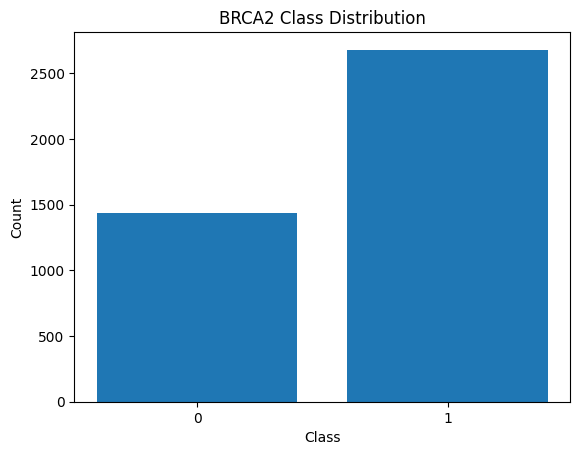

In [64]:
warnings.filterwarnings('ignore')

for variant_name in variant_names:    
    curr_vus = vus[variant_name]
    curr_classified = classified[variant_name]
    curr_unclassified = unclassified[variant_name]
    curr_leftover = leftover[variant_name]
    
    # if len(curr_classified) < 10:
    #     continue
    
    vus_df = variants_to_dataframe(curr_vus)
    classified_df = variants_to_dataframe(curr_classified)
    unclassified_df = variants_to_dataframe(curr_unclassified)
    leftover_df = variants_to_dataframe(curr_leftover)
    
    all_variants_df_raw = variants_to_dataframe_unprocessed(all_variants_raw[variant_name])
    all_variants_df_processed = variants_to_dataframe(all_variants_processed[variant_name])
    
    class_counts = classified_df["label"].value_counts().sort_index()
    
    # print(all_variants_df_raw.columns)
    
#     hgvs_c_cols = ["HGVSc_VEP"]
#     tmp = all_variants_df_raw[hgvs_c_cols].bfill(axis=1).iloc[:, 0]  # first non-null
    
#     # all_variants_df_raw["HGVS_c"] = tmp.where(tmp.str.contains(r":c\.", na=False))  # keep only transcript c.
# # take first c. entry per row
#     all_variants_df_raw["HGVSc_VEP"] = all_variants_df_raw["HGVSc_VEP"].str.split("&").str[0]
#     all_variants_df_processed["HGVSc_VEP"] = all_variants_df_raw["HGVSc_VEP"].str.split("&").str[0]
#     vus_df["HGVSc_VEP"] = all_variants_df_raw["HGVSc_VEP"].str.split("&").str[0]
#     classified_df["HGVSc_VEP"] = all_variants_df_raw["HGVSc_VEP"].str.split("&").str[0]
#     leftover_df["HGVSc_VEP"] = all_variants_df_raw["HGVSc_VEP"].str.split("&").str[0]
    # if class_counts.get(1) == None:
    #     continue
    
    dir_name = f"bio/{variant_name}"
    os.makedirs(f"data/{dir_name}", exist_ok=True)
    
    vus_df.to_csv(f"data/{dir_name}/vus_{variant_name}_{len(curr_vus)}_bio.txt", sep="\t", index=False, na_rep=999)
    classified_df.to_csv(f"data/{dir_name}/classified_{variant_name}_{len(curr_classified)}_bio.txt", sep="\t", index=False, na_rep=999)
    unclassified_df.to_csv(f"data/{dir_name}/unclassified_{variant_name}_{len(curr_unclassified)}_bio.txt", sep="\t", index=False, na_rep=999)
    leftover_df.to_csv(f"data/{dir_name}/leftover_{variant_name}_{len(curr_leftover)}_bio.txt", sep="\t", index=False, na_rep=999)

    all_variants_df_raw.to_csv(f"data/{dir_name}/all_variants_raw_2{variant_name}_{len(all_variants_raw[variant_name])}_bio.csv", sep=",", index=False)
    all_variants_df_processed.to_csv(f"data/{dir_name}/all_variants_processed_{variant_name}_{len(all_variants_processed[variant_name])}_bio.csv", sep=",", index=False)

    print(class_counts)
    
    plt.bar(class_counts.index, class_counts.values)
    plt.xticks([0, 1])
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title(f"{variant_name} Class Distribution")
    plt.show()